simulation stochstique 1

1
1.1808191808191808


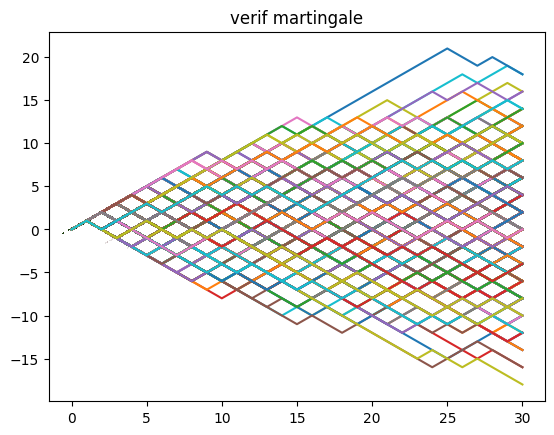

In [4]:
from numpy.random import rand
import numpy as np
import matplotlib.pyplot as plt

def X(): #P(X=1)=1/2, P(X=-1)=1/2
    if rand() <= 1/2:
        res = 1
    else:
        res = -1
    return res

def processus_M(K): #construire une marche aléatoire symétrique jusqu'au temps K
    M = [0]         #M_i+1 = M_i +X_i+1
    for i in range(0,K): 
        M.append(M[i]+X())
    return M[K], M

def verifacation_martingale(K,n,N_mc): #E[M_n|F_k] = M_k
    last_values = [0]
    M_k, M_old = processus_M(K) #on tire une marche aléatoire jusqu'à K
    for p in range(0,N_mc):     
        M = M_old[:] #on copie la liste
        for i in range(K,n):
            M.append(M[i]+X())
        plt.plot(M)
        plt.title("verif martingale") #trajectoire de martingale
        last_values.append(M[n])
    esperance_cond = np.mean(last_values)
    print(M_k)            #valeur théorique
    print(esperance_cond) #moyenne empirique

verifacation_martingale(K=1, n=30, N_mc=1000)




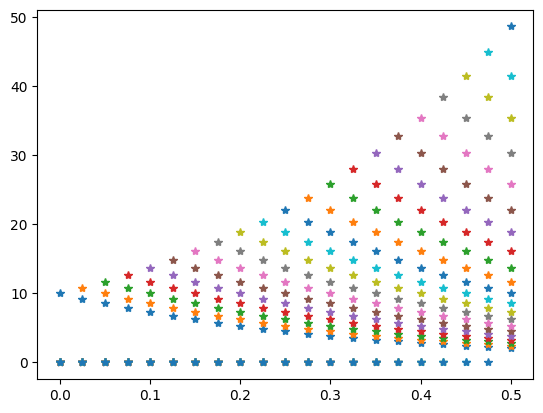

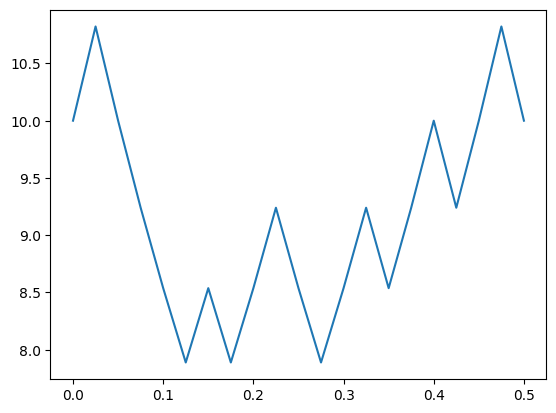

pratique= 10.91873425921747
théorie= 10.512710963760261


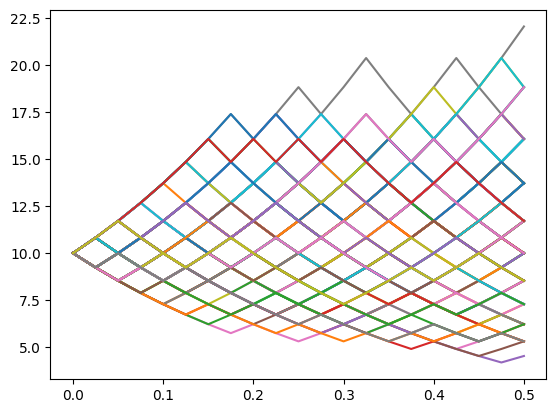

In [ ]:
from numpy.random import rand
import numpy as np
import matplotlib.pyplot as plt

S0=10
T=0.5
N=20
delta_t = T/N
sigma = 0.5
r=0.1
u = np.exp(sigma * np.sqrt(delta_t))
d = np.exp(-sigma * np.sqrt(delta_t))
p = (np.exp(r * delta_t)-d) / (u-d)
t=np.linspace(0,T,N+1)
S=np.zeros((N+1,N+1))
for n in range(N+1):
    for i in range(n+1):
        S[n,i] = S0 * u**i * d**(n-i)
plt.plot(t,S,'*')
plt.show()
S_mc = np.zeros(N+1)
S_mc[0] = S0

for n in range(0,N):
    if rand() < p:
        S_mc[n+1] = u * S_mc[n]
    else:
        S_mc[n+1] = d * S_mc[n]
plt.plot(t,S_mc)
plt.show()

last_values = []
N_mc = 100
for k in range(1,N_mc):
    for n in range(N):
        if rand() < p:
            S_mc[n+1] = u * S_mc[n]
        else:
            S_mc[n+1] = d * S_mc[n]
    plt.plot(t, S_mc)
    last_values.append(S_mc[N])
esp_mc = np.mean(last_values)
esp_th = S0 * (p*u+(1-p)*d)**N
print("pratique=",esp_mc)
print("théorie=",esp_th)
plt.show()




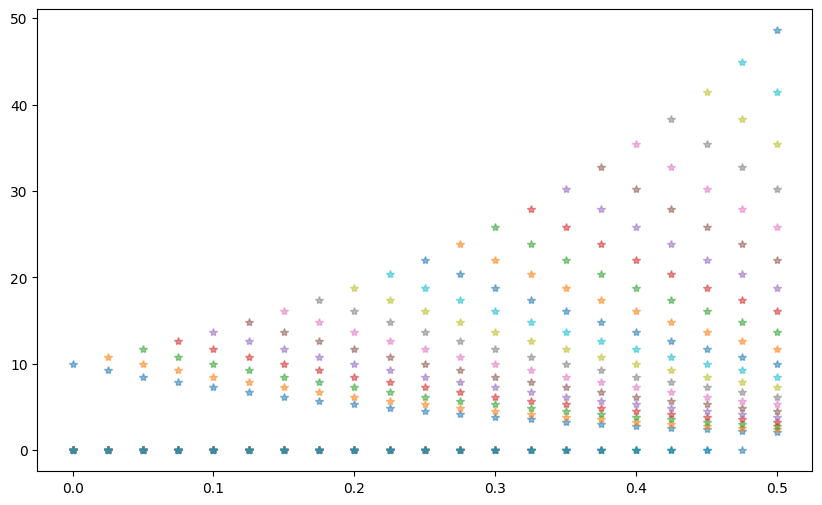

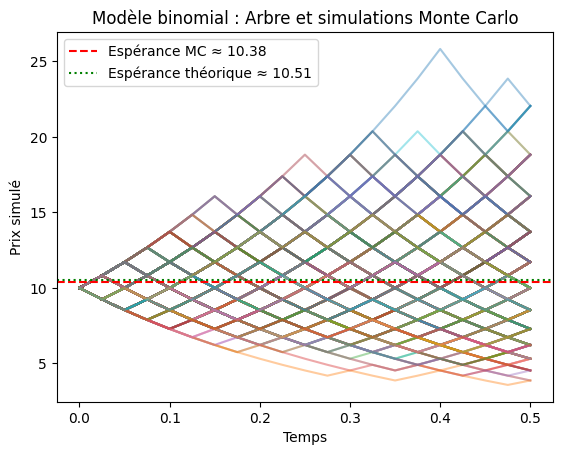

In [12]:
from numpy.random import rand
import numpy as np
import matplotlib.pyplot as plt

# --- Paramètres ---
S0 = 10       # prix initial
T = 0.5       # horizon
N = 20        # nombre de pas
delta_t = T / N
sigma = 0.5
r = 0.1

# --- Paramètres du modèle binomial ---
u = np.exp(sigma * np.sqrt(delta_t))
d = np.exp(-sigma * np.sqrt(delta_t))
p = (np.exp(r * delta_t) - d) / (u - d)

t = np.linspace(0, T, N+1)

# --- Arbre binomial théorique ---
S = np.zeros((N+1, N+1))
for n in range(N+1):
    for i in range(n+1):
        S[n, i] = S0 * u**i * d**(n-i)

plt.figure(figsize=(10,6))
plt.plot(t, S, '*', label="Arbre binomial (théorique)", alpha=0.5)
plt.show()

# --- Simulations Monte Carlo ---
N_mc = 500    # nombre de trajectoires
last_values = []

for k in range(N_mc):
    S_mc = np.zeros(N+1)
    S_mc[0] = S0
    for n in range(N):
        if rand() < p:
            S_mc[n+1] = u * S_mc[n]
        else:
            S_mc[n+1] = d * S_mc[n]
    last_values.append(S_mc[N])
    plt.plot(t, S_mc, alpha=0.4)

# --- Espérance empirique et théorique ---
esp_mc = np.mean(last_values)
esp_th = S0 * (p*u + (1-p)*d)**N

plt.axhline(esp_mc, color="red", linestyle="--", label=f"Espérance MC ≈ {esp_mc:.2f}")
plt.axhline(esp_th, color="green", linestyle=":", label=f"Espérance théorique ≈ {esp_th:.2f}")

plt.xlabel("Temps")
plt.ylabel("Prix simulé")
plt.title("Modèle binomial : Arbre et simulations Monte Carlo")
plt.legend()
plt.show()




In [ ]:
#coder modèle binomial, révision, martingale